In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import cv2
import zipfile
import hashlib

from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import AdamW, Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import EfficientNetB3
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.losses import CategoricalFocalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D, LeakyReLU, AveragePooling2D
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix

In [3]:
from pathlib import Path
import os
import shutil
import random

Split data into folders

In [4]:
#script_path = os.path.dirname(os.path.abspath(__file__))
script_path = ""
original_folder = os.path.join(script_path, "EuroSAT_RGB")
base_folder = os.path.join(script_path, "EuroSAT_RGB_split")

In [5]:
def split_data():
    train_ratio = 0.7
    val_ratio = 0.15
    random_state = 42
    random.seed(random_state)

    for split in ["train", "validate", "test"]:
        os.makedirs(os.path.join(base_folder, split), exist_ok=True)
    
    for class_name in os.listdir(original_folder):
        class_path = os.path.join(original_folder, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path) if f.lower().endswith((".jpg", ".png", ".tif"))]
        random.shuffle(images)

        n_total = len(images)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        splits = {
            "train": images[:n_train],
            "validate": images[n_train:n_train + n_val],
            "test": images[n_train + n_val:]
        }

        for split_name, split_images in splits.items():
            split_dir = os.path.join(base_folder, split_name, class_name)
            os.makedirs(split_dir, exist_ok=True)

            for img_name in split_images:
                src = os.path.join(class_path, img_name)
                dst = os.path.join(split_dir, img_name)
                shutil.copy(src, dst)

        print(f"{class_name}: {n_total} images split into train/val/test")

In [6]:
#split_data()
# took 3 mins

AnnualCrop: 3000 images split into train/val/test

Forest: 3000 images split into train/val/test

HerbaceousVegetation: 3000 images split into train/val/test

Highway: 2500 images split into train/val/test

Industrial: 2500 images split into train/val/test

Pasture: 2000 images split into train/val/test

PermanentCrop: 2500 images split into train/val/test

Residential: 3000 images split into train/val/test

River: 2500 images split into train/val/test

SeaLake: 3000 images split into train/val/test


In [7]:
train_dir = os.path.join(base_folder, "train")
val_dir = os.path.join(base_folder, "validate")
test_dir = os.path.join(base_folder, "test")

In [8]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False 
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False 
)

Found 18900 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.


In [ ]:
# import tensorflow as tf
# print("TensorFlow version:", tf.__version__)
# print("GPUs available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPUs available: []


In [ ]:
# import os, tensorflow as tf
# print(tf.sysconfig.get_build_info()["cuda_version"])
# print(tf.sysconfig.get_build_info()["cudnn_version"])

KeyError: 'cuda_version'

In [ ]:
# from tensorflow.python.platform import build_info
# print(build_info.build_info)


OrderedDict({'is_cuda_build': False, 'is_rocm_build': False, 'is_tensorrt_build': False, 'msvcp_dll_names': 'msvcp140.dll,msvcp140_1.dll'})


In [13]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 16350525004020771610
xla_global_id: -1
]


In [21]:
class_labels = train_generator.classes
class_weight_dict = dict(
    enumerate(
        compute_class_weight('balanced', classes=np.unique(class_labels), y=class_labels)
    )
)

model = Sequential([
    *[
        layer
        for filters in [64, 128, 256, 512]
        for layer in (
            [Conv2D(filters, 3, activation='relu', padding='same', kernel_regularizer=l2(0.001)),
             BatchNormalization(),
             MaxPooling2D(2)]
        )
    ],
    GlobalAveragePooling2D(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer=Adam(1e-4),
    loss=CategoricalFocalCrossentropy(gamma=2.0),
    metrics=['accuracy']
)

callbacks = [
    ModelCheckpoint(
        'checkpoints/best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6)
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=callbacks
)


c:\Users\S1NdBAD\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 268s 446ms/step - accuracy: 0.6658 - loss: 1.0273 - val_accuracy: 0.4454 - val_loss: 1.1001 - learning_rate: 1.0000e-04
Epoch 2/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 152s 257ms/step - accuracy: 0.7631 - loss: 0.8410 - val_accuracy: 0.8109 - val_loss: 0.7523 - learning_rate: 1.0000e-04
Epoch 3/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 146s 248ms/step - accuracy: 0.8028 - loss: 0.7005 - val_accuracy: 0.8323 - val_loss: 0.6259 - learning_rate: 1.0000e-04
Epoch 4/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 142s 241ms/step - accuracy: 0.8380 - loss: 0.5763 - val_accuracy: 0.8252 - val_loss: 0.5319 - learning_rate: 1.0000e-04
Epoch 5/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 144s 244ms/step - accuracy: 0.8559 - loss: 0.4773 - val_accuracy: 0.7820 - val_loss: 0.4769 - learning_rate: 1.0000e-04
Epoch 6/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 151s 256ms/step - accuracy: 0.8712 - loss: 0.3932 - val_accuracy: 0.8714 - val_loss: 0.3628 - learning_rate: 1.0000e-04
Epoch 7/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 

In [22]:
model.save("SataliteClassification.keras")
#loaded_model = tf.keras.models.load_model("SataliteClassification.keras")

test

In [44]:
def evaluate_model(model, test_ds, class_names):
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f"\nTest Results:\nAccuracy: {test_acc:.4f} | Loss: {test_loss:.4f}")

    preds = model.predict(test_ds, verbose=1)
    y_pred = np.argmax(preds, axis=1)

    if hasattr(test_ds, 'labels'):
        y_true = test_ds.labels
    else:
        y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds], axis=0)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    print('\nClassification Report:\n')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    return test_acc, test_loss, y_true, y_pred


Test Results:
Accuracy: 0.9714 | Loss: 0.0322
127/127 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step


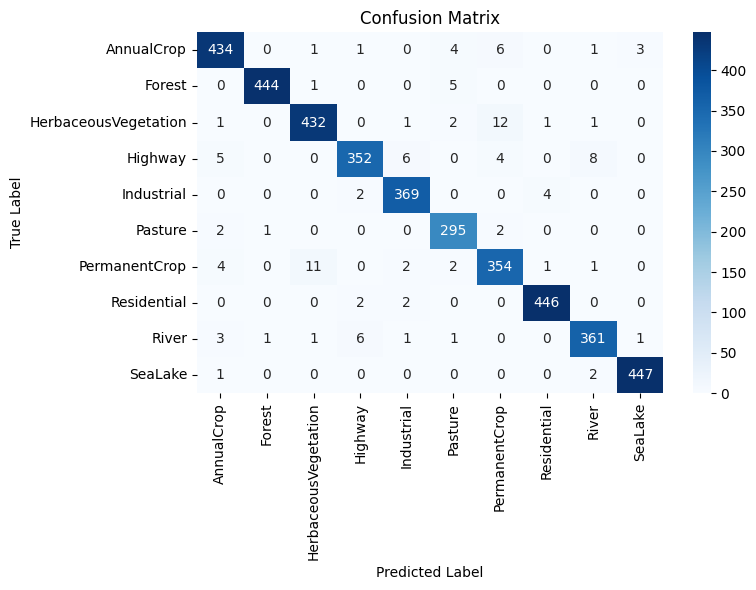


Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop     0.9644    0.9644    0.9644       450
              Forest     0.9955    0.9867    0.9911       450
HerbaceousVegetation     0.9686    0.9600    0.9643       450
             Highway     0.9697    0.9387    0.9539       375
          Industrial     0.9685    0.9840    0.9762       375
             Pasture     0.9547    0.9833    0.9688       300
       PermanentCrop     0.9365    0.9440    0.9402       375
         Residential     0.9867    0.9911    0.9889       450
               River     0.9652    0.9627    0.9640       375
             SeaLake     0.9911    0.9933    0.9922       450

            accuracy                         0.9714      4050
           macro avg     0.9701    0.9708    0.9704      4050
        weighted avg     0.9714    0.9714    0.9713      4050

Test Accuracy: 0.9714
Test Loss: 0.0322


In [45]:
test_acc, test_loss, y_true, y_pred = evaluate_model(model, test_generator, list(test_generator.class_indices.keys()))
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

In [ ]:
def plot_training_curves(model, test_acc=0):
    acc = model.history['accuracy']
    val_acc = model.history['val_accuracy']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    plt.plot(epochs_range, acc, label='Train Acc')
    plt.plot(epochs_range, val_acc, label='Val Acc')
    plt.axhline(y=test_acc, linestyle='--', color='green', label=f'Test Acc: {test_acc:.2f}')
    plt.title('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

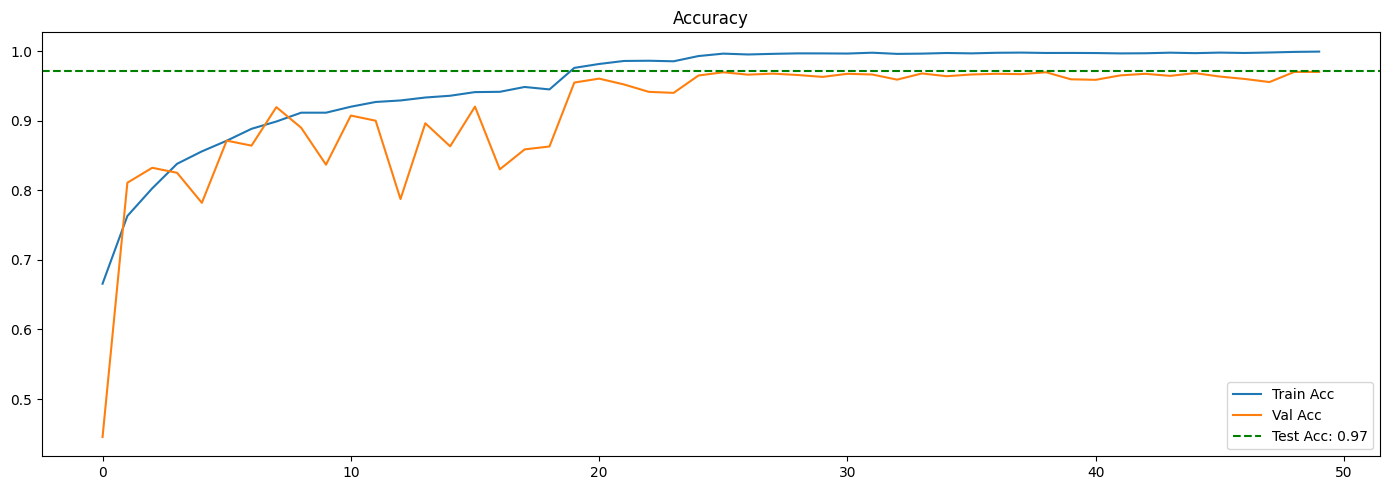

In [47]:
plot_training_curves(history, test_acc=test_acc)

Randomly selected image:
D:\Coding\Jupyter\DEPI\DEPI-Final-Project\Dataset\Project 6 Datasets\EuroSAT_RGB_split\test\Pasture\Pasture_1049.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


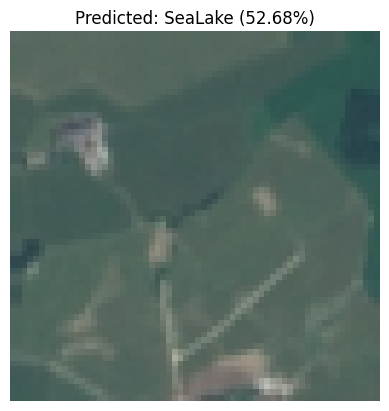


✅ Model prediction: SeaLake (52.68% confidence)


In [59]:
split = 'D:\\Coding\\Jupyter\\DEPI\\DEPI-Final-Project\\Dataset\\Project 6 Datasets\\EuroSAT_RGB_split\\test' 
img_size = (128, 128)  
data_dir = '' 
class_names = list(test_generator.class_indices.keys())

all_image_paths = []
split_dir = os.path.join(data_dir, split)
for class_dir in os.listdir(split_dir):
    class_path = os.path.join(split_dir, class_dir)
    if os.path.isdir(class_path):
        for fname in os.listdir(class_path):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_image_paths.append(os.path.join(class_path, fname))

random_image_path = random.choice(all_image_paths)
print(f"Randomly selected image:\n{random_image_path}")

img = cv2.imread(random_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, img_size)
img_array = np.expand_dims(img_resized, axis=0) / 255.0  # normalize like ImageDataGenerator

pred = model.predict(img_array)
pred_class = class_names[np.argmax(pred)]
confidence = np.max(pred)

plt.imshow(img)
plt.title(f"Predicted: {pred_class} ({confidence:.2%})")
plt.axis('off')
plt.show()

print(f"\n✅ Model prediction: {pred_class} ({confidence:.2%} confidence)")